# Comparing model performance with a simple baseline

- Compare the genralization performace with a model to a minimal baseline
- Use the `DummyRegressor` class to predict the mean target value observed on the training set without using the input features.  

In [2]:
from sklearn.datasets import fetch_california_housing

data, target = fetch_california_housing(return_X_y=True, as_frame=True)
target *= 100  # rescale the target in k$

In [3]:
from sklearn.model_selection import ShuffleSplit

cv = ShuffleSplit(n_splits=30, test_size=0.2, random_state=0)

## Dummy Classifier
- It does not try to learn relationships from the data but instead uses simple rules to make predictions.
- **Parameter :** `strategy`<br> <br>
- `most_frequent :` Predicts the most frequent class in the training data.
- `prior :` Predicts according to the class prior probabilities in the training data.
- `stratified :` Generates predictions by respecting the class distribution in the training data.
- `uniform :` Generates predictions uniformly at random.
- `constant :` Always predicts a user-specified constant (requires the constant parameter)
- **Paramater :** `constant` A user-defined constant for the 'constant' strategy. 

In [4]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate

regressor = DecisionTreeRegressor()
cv_results_tree_regressor = cross_validate(
    regressor, data, target, cv=cv, scoring="neg_mean_absolute_error", n_jobs=2
)

errors_tree_regressor = pd.Series(
    -cv_results_tree_regressor["test_score"], name="Decision tree regressor"
)
errors_tree_regressor.describe()

count    30.000000
mean     45.667877
std       1.167078
min      43.111206
25%      44.907639
50%      45.699763
75%      46.335560
max      47.806366
Name: Decision tree regressor, dtype: float64

In [5]:
from sklearn.dummy import DummyRegressor

dummy = DummyRegressor(strategy="mean")
result_dummy = cross_validate(
    dummy, data, target, cv=cv, scoring="neg_mean_absolute_error", n_jobs=2
)
errors_dummy_regressor = pd.Series(
    -result_dummy["test_score"], name="Dummy regressor"
)
errors_dummy_regressor.describe()

count    30.000000
mean     91.140009
std       0.821140
min      89.757566
25%      90.543652
50%      91.034555
75%      91.979007
max      92.477244
Name: Dummy regressor, dtype: float64

In [6]:
all_errors = pd.concat(
    [errors_tree_regressor, errors_dummy_regressor],
    axis=1,
)
all_errors

,Decision tree regressor,Dummy regressor
0,47.166297,90.713153
1,46.936696,90.539353
2,44.279813,91.941912
3,43.805345,90.213912
4,47.687425,92.015862
5,45.237880,90.542490
6,43.889427,89.757566
7,44.917799,92.477244
8,44.791100,90.947952
9,44.904253,91.991373


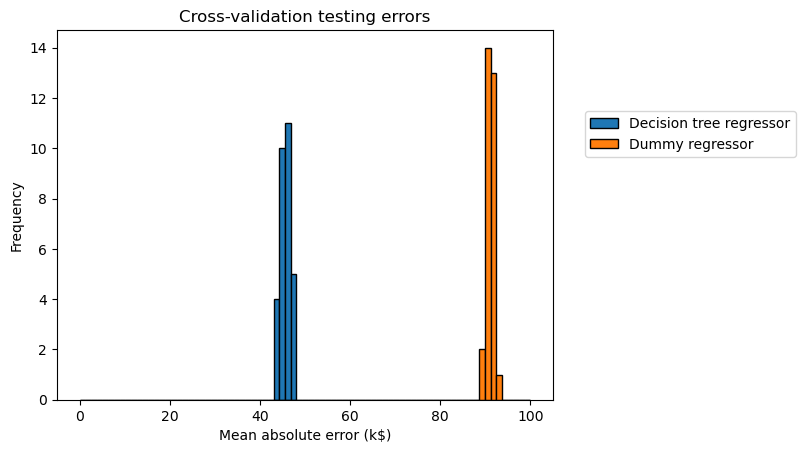

In [7]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(start=0, stop=100, num=80)
all_errors.plot.hist(bins=bins, edgecolor="black")
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.xlabel("Mean absolute error (k$)")
_ = plt.title("Cross-validation testing errors")

- this confirms that it is possible to predict the housing price much better by using a model that takes into account the values of the input features (housing location, size, neighborhood income...). Such a model makes more informed predictions and approximately divides the error rate by a factor of 2 compared to the baseline that ignores the input features.